<a href="https://colab.research.google.com/github/saisathwik2703/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/saisathwik2703/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Ranked action queue

The playbook converts the validated model output into a review queue rather than an automatic publishing system.

Pages are ranked using the out-of-sample model score from the client-grouped validation. The score is used to prioritize review, while transparent reason codes explain the main observable signals behind each recommendation.

The queue uses the existing rule-based reason codes for human-readable explanations. These include stale visible pages, declining pages with existing demand, thin visible pages, page-one decay risk, low CTR, and low engagement.

The ranking is decision-support: a higher score means the page is ranked earlier for review in this dataset. It does not mean that an action will definitely improve search performance.

In [3]:
# ============================================================
# ML-10 SECTION 1
# Ranked actions + reason codes
# ============================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# 1. Locate / clone repository
# ------------------------------------------------------------

repo = "/content/flyrank-ml-internship-starter"

if not os.path.exists(repo):
    !git clone -q https://github.com/flyrank-bih/flyrank-ml-internship-starter.git

raw_path = os.path.join(
    repo,
    "data",
    "raw",
    "content_refresh_anonymized.csv"
)

df = pd.read_csv(raw_path)

print("Dataset shape:", df.shape)


# ------------------------------------------------------------
# 2. Target
# ------------------------------------------------------------

df["target"] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)


# ------------------------------------------------------------
# 3. Same 19 Week-5 features
# ------------------------------------------------------------

feature_cols = [
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "days_since_last_update",
    "word_count",
    "char_count",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]


# ------------------------------------------------------------
# 4. Prepare features
# ------------------------------------------------------------

for col in feature_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    ).fillna(0)

X = df[feature_cols].copy()
y = df["target"].copy()
groups = df["client_id"].astype(str)


# ------------------------------------------------------------
# 5. Client-grouped split
# ------------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, review_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx]
X_review = X.iloc[review_idx]

y_train = y.iloc[train_idx]
y_review = y.iloc[review_idx]

review_df = df.iloc[review_idx].copy()


# ------------------------------------------------------------
# 6. Check client separation
# ------------------------------------------------------------

train_clients = set(groups.iloc[train_idx])
review_clients = set(groups.iloc[review_idx])

client_overlap = train_clients.intersection(
    review_clients
)

print("\nCLIENT HOLDOUT CHECK")
print("--------------------")
print("Training clients:", len(train_clients))
print("Review clients:", len(review_clients))
print("Client overlap:", len(client_overlap))


# ------------------------------------------------------------
# 7. Train validated Logistic Regression
# ------------------------------------------------------------

validated_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

validated_model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 8. Out-of-sample review scores
# ------------------------------------------------------------

review_df["validated_model_score"] = (
    validated_model.predict_proba(X_review)[:, 1]
)

print(
    "\nReview rows:",
    len(review_df)
)


# ------------------------------------------------------------
# 9. Transparent reason codes
# ------------------------------------------------------------

def reason_codes(row):

    reasons = []

    if (
        row["days_since_last_update"] >= 180
        and row["impressions_90d"] >= 500
    ):
        reasons.append("stale_visible_page")

    if (
        str(row["trend_direction"]).lower() == "down"
        and row["impressions_90d"] >= 100
    ):
        reasons.append("declining_with_demand")

    if (
        row["word_count"] > 0
        and row["word_count"] < 1200
        and row["impressions_90d"] >= 250
    ):
        reasons.append("thin_visible_page")

    if (
        row["avg_position"] > 0
        and row["avg_position"] <= 10
        and row["content_age_days"] >= 180
    ):
        reasons.append("page_one_decay_risk")

    if (
        row["impressions_90d"] >= 500
        and 0 < row["avg_position"] <= 20
        and row["ctr"] < 0.5
    ):
        reasons.append("low_ctr_visible_page")

    if (
        row["sessions_90d"] >= 30
        and (
            (
                row["engagement_rate"] > 0
                and row["engagement_rate"] < 30
            )
            or
            (
                row["scroll_rate"] > 0
                and row["scroll_rate"] < 30
            )
        )
    ):
        reasons.append("low_engagement_visible_page")

    if not reasons:
        reasons.append("general_refresh_review")

    return reasons


review_df["reason_codes"] = review_df.apply(
    reason_codes,
    axis=1
)

review_df["reason_codes_text"] = (
    review_df["reason_codes"]
    .apply(lambda x: "|".join(x))
)


# ------------------------------------------------------------
# 10. Archetype → action mapping
# ------------------------------------------------------------

def choose_archetype_action(reasons):

    reasons = set(reasons)

    if "low_ctr_visible_page" in reasons:
        return (
            "CTR opportunity",
            "refresh_and_review_ctr"
        )

    if "thin_visible_page" in reasons:
        return (
            "Content depth",
            "expand_and_refresh"
        )

    if (
        "stale_visible_page" in reasons
        or "declining_with_demand" in reasons
    ):
        return (
            "Refresh / decay",
            "refresh"
        )

    if "page_one_decay_risk" in reasons:
        return (
            "Page-one opportunity",
            "review_title_description"
        )

    if "low_engagement_visible_page" in reasons:
        return (
            "Engagement review",
            "improve_scanability"
        )

    return (
        "General review",
        "monitor"
    )


mapped = review_df["reason_codes"].apply(
    choose_archetype_action
)

review_df["archetype"] = mapped.apply(
    lambda x: x[0]
)

review_df["suggested_action"] = mapped.apply(
    lambda x: x[1]
)


# ------------------------------------------------------------
# 11. Impact proxy
# ------------------------------------------------------------
# This is NOT revenue.
# It only represents existing search visibility exposure.

review_df["impact_proxy"] = np.log1p(
    review_df["impressions_90d"]
)


# ------------------------------------------------------------
# 12. Effort bands
# ------------------------------------------------------------

effort_map = {
    "refresh": "medium",
    "expand_and_refresh": "high",
    "refresh_and_review_ctr": "low",
    "review_title_description": "low",
    "improve_scanability": "medium",
    "monitor": "low"
}

review_df["effort"] = (
    review_df["suggested_action"]
    .map(effort_map)
    .fillna("medium")
)


# ------------------------------------------------------------
# 13. Value tier
# ------------------------------------------------------------

impact_q75 = review_df["impact_proxy"].quantile(0.75)
impact_q50 = review_df["impact_proxy"].quantile(0.50)

def value_tier(value):

    if value >= impact_q75:
        return "high_visibility"

    if value >= impact_q50:
        return "medium_visibility"

    return "lower_visibility"


review_df["value_tier"] = (
    review_df["impact_proxy"]
    .apply(value_tier)
)


# ------------------------------------------------------------
# 14. Rank the review queue
# ------------------------------------------------------------

review_df = review_df.sort_values(
    [
        "validated_model_score",
        "impact_proxy"
    ],
    ascending=False
).reset_index(drop=True)

review_df["priority_rank"] = (
    np.arange(len(review_df)) + 1
)


# ------------------------------------------------------------
# 15. Keep only public-safe queue fields
# ------------------------------------------------------------

queue_columns = [
    "priority_rank",
    "content_id",
    "validated_model_score",
    "reason_codes_text",
    "archetype",
    "suggested_action",
    "impact_proxy",
    "value_tier",
    "effort",
    "impressions_90d",
    "avg_position",
    "ctr",
    "content_age_days",
    "days_since_last_update",
    "word_count"
]

action_queue = review_df[
    queue_columns
].copy()


# ------------------------------------------------------------
# 16. Display top 20
# ------------------------------------------------------------

print("\nTOP 20 REVIEW ACTIONS")
print("---------------------")

display(
    action_queue.head(20).round(4)
)


# ------------------------------------------------------------
# 17. Queue summary
# ------------------------------------------------------------

print("\nACTION COUNTS")
print("-------------")

display(
    action_queue["suggested_action"]
    .value_counts()
    .to_frame("count")
)

print(
    "\nReason-code coverage:"
)

display(
    action_queue["archetype"]
    .value_counts()
    .to_frame("count")
)

Dataset shape: (30000, 44)

CLIENT HOLDOUT CHECK
--------------------
Training clients: 25
Review clients: 7
Client overlap: 0

Review rows: 6163

TOP 20 REVIEW ACTIONS
---------------------


,priority_rank,content_id,validated_model_score,reason_codes_text,archetype,suggested_action,impact_proxy,value_tier,effort,impressions_90d,avg_position,ctr,content_age_days,days_since_last_update,word_count
0,1,content_b08562686d22,0.8913,declining_with_demand|low_ctr_visible_page,CTR opportunity,refresh_and_review_ctr,7.9540,high_visibility,low,2846,2.0,0.14,106,106,2900.0
1,2,content_453722754fea,0.8876,declining_with_demand|low_ctr_visible_page,CTR opportunity,refresh_and_review_ctr,11.8500,high_visibility,low,140079,7.6,0.01,97,20,2700.0
2,3,content_8ede62882d0b,0.8798,declining_with_demand|low_ctr_visible_page,CTR opportunity,refresh_and_review_ctr,6.3226,medium_visibility,low,556,14.3,0.00,117,20,2660.0
3,4,content_c84a0ab98e90,0.8694,low_ctr_visible_page|low_engagement_visible_page,CTR opportunity,refresh_and_review_ctr,12.3161,high_visibility,low,223271,7.8,0.03,95,20,2871.0
4,5,content_26d48a980581,0.8661,low_ctr_visible_page,CTR opportunity,refresh_and_review_ctr,7.1444,medium_visibility,low,1266,4.6,0.00,106,106,2849.0
5,6,content_c94a53e3bfb8,0.8608,low_ctr_visible_page,CTR opportunity,refresh_and_review_ctr,7.6802,medium_visibility,low,2164,8.1,0.23,95,20,2737.0
6,7,content_87c007fb5c26,0.8590,declining_with_demand|low_ctr_visible_page,CTR opportunity,refresh_and_review_ctr,7.8095,high_visibility,low,2463,6.6,0.00,97,20,2853.0
7,8,content_b51992d6cbc2,0.8530,declining_with_demand|low_ctr_visible_page,CTR opportunity,refresh_and_review_ctr,7.3645,medium_visibility,low,1578,4.9,0.32,97,20,2746.0
8,9,content_b872486bfd10,0.8499,declining_with_demand|low_ctr_visible_page,CTR opportunity,refresh_and_review_ctr,8.4547,high_visibility,low,4696,2.3,0.04,106,20,2668.0
9,10,content_5c7ccee8cd9e,0.8494,declining_with_demand|low_ctr_visible_page,CTR opportunity,refresh_and_review_ctr,6.3404,medium_visibility,low,566,6.1,0.00,145,20,3052.0



ACTION COUNTS
-------------


,count
suggested_action,
monitor,2457
refresh_and_review_ctr,1827
refresh,1131
review_title_description,676
improve_scanability,72



Reason-code coverage:


,count
archetype,
General review,2457
CTR opportunity,1827
Refresh / decay,1131
Page-one opportunity,676
Engagement review,72


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

The playbook is intended for a content or SEO reviewer who needs to decide which pages to inspect first.

The ranked score is a prioritization signal. Reason codes provide a human-readable explanation of the observable conditions associated with the recommendation.

A reviewer can use the queue to select a small batch of pages for manual investigation, such as checking freshness, search visibility, CTR, content depth, or reader engagement.

### Limits

The queue is based on a 30,000-row anonymized starter dataset and a client-grouped validation design. It is not a production system and should not be treated as a guarantee of future search performance.

The model score ranks pages for review; it does not establish that an edit will cause traffic, rankings, clicks, or revenue to increase.

The impact proxy is based on existing impressions and is not a revenue estimate.

The starter dataset is a trailing 90-day snapshot and does not provide a full observation-date field for chronological production validation. Therefore, temporal generalization remains a limitation.

The queue should be refreshed when the underlying data becomes stale and should be reviewed by a human before any content change is made.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# ============================================================
# SECTION 2
# Intended use and limits
# ============================================================

intended_use_checks = pd.DataFrame({
    "Check": [
        "Out-of-sample scoring",
        "Client overlap",
        "Uses revenue estimate",
        "Autonomous publishing",
        "Human review required",
        "Production guarantee"
    ],
    "Status": [
        "Yes",
        "No",
        "No",
        "No",
        "Yes",
        "No"
    ]
})

display(intended_use_checks)

print(
    "Rows available for decision-support review:",
    len(action_queue)
)

print(
    "Unique review clients:",
    action_queue.shape[0]
    if "client_id" not in action_queue.columns
    else action_queue["client_id"].nunique()
)

print(
    "\nImportant: impact_proxy is a visibility proxy, "
    "not a monetary value."
)

,Check,Status
0,Out-of-sample scoring,Yes
1,Client overlap,No
2,Uses revenue estimate,No
3,Autonomous publishing,No
4,Human review required,Yes
5,Production guarantee,No


Rows available for decision-support review: 6163
Unique review clients: 6163

Important: impact_proxy is a visibility proxy, not a monetary value.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review rules

Every recommended action requires human review before implementation.

The reviewer should confirm that the page is still relevant, that the reason code matches the current page, that the proposed change is factually correct, and that there is no competing page, business constraint, or editorial requirement that changes the recommendation.

For refresh recommendations, the reviewer should check whether the page actually contains outdated information and identify what needs updating.

For CTR recommendations, the reviewer should inspect the search intent, title, description, and position before making a change.

For content-depth recommendations, the reviewer should identify missing useful topics, examples, definitions, or comparisons rather than adding filler.

### No-go list

The system should never autonomously publish, delete, redirect, merge, canonicalize, or materially rewrite content.

It should not make legal, medical, financial, safety, or other high-stakes claims without appropriate human review.

It should not infer that a model score proves a page is bad or that an action will improve rankings.

It should not use the queue as a substitute for factual verification, editorial judgment, or business priorities.

The model is a prioritization aid, not an autonomous content decision-maker.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# ============================================================
# SECTION 3
# Human review + no-go list
# ============================================================

review_rules = pd.DataFrame({
    "Action": [
        "Refresh content",
        "Review CTR",
        "Expand content",
        "Improve scanability",
        "Monitor"
    ],
    "Human_check_required": [
        True,
        True,
        True,
        True,
        True
    ],
    "Automatic_publish_allowed": [
        False,
        False,
        False,
        False,
        False
    ]
})

display(review_rules)


no_go_actions = [
    "automatic publishing",
    "automatic deletion",
    "automatic redirects",
    "automatic canonical changes",
    "automatic page merging",
    "unverified factual rewriting",
    "high-stakes claims without review"
]

print("NO-GO ACTIONS")
print("--------------")

for i, action in enumerate(no_go_actions, 1):
    print(f"{i}. {action}")

print(
    "\nAll recommended actions require human review:",
    review_rules["Human_check_required"].all()
)

print(
    "Automatic publishing disabled:",
    (~review_rules["Automatic_publish_allowed"]).all()
)

,Action,Human_check_required,Automatic_publish_allowed
0,Refresh content,True,False
1,Review CTR,True,False
2,Expand content,True,False
3,Improve scanability,True,False
4,Monitor,True,False


NO-GO ACTIONS
--------------
1. automatic publishing
2. automatic deletion
3. automatic redirects
4. automatic canonical changes
5. automatic page merging
6. unverified factual rewriting
7. high-stakes claims without review

All recommended actions require human review: True
Automatic publishing disabled: True


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring plan

The playbook should be monitored for both data drift and outcome drift.

Data drift means the distribution of important inputs changes, such as impressions, content age, average position, CTR, or days since update.

Model drift means the out-of-sample ranking metrics fall when new labeled data becomes available. Average Precision and ROC-AUC should be checked on a consistent holdout design, preferably grouped by client.

Action drift means the queue starts producing a very different mix of reason codes or actions. A large shift should trigger investigation rather than automatic retraining.

### Retrain / review triggers

A review should be triggered when:

1. New labeled data becomes available from a later period.
2. Model Average Precision or ROC-AUC declines materially relative to the validation reference.
3. The distribution of major features changes substantially.
4. The proportion of pages in major reason-code groups changes sharply.
5. Human reviewers repeatedly reject or override the same recommendation.
6. The content lifecycle or refresh pattern changes enough that the current rules may no longer represent the observed data.

Retraining should be preceded by leakage checks and a fresh grouped or time-aware validation rather than being triggered solely by a single metric change.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# ============================================================
# SECTION 4
# Monitoring / retrain triggers
# ============================================================

# Current reference distributions
monitor_features = [
    "impressions_90d",
    "content_age_days",
    "days_since_last_update",
    "avg_position",
    "ctr"
]

reference_summary = pd.DataFrame({
    "feature": monitor_features,
    "median": [
        df[col].median()
        for col in monitor_features
    ],
    "mean": [
        df[col].mean()
        for col in monitor_features
    ],
    "p90": [
        df[col].quantile(0.90)
        for col in monitor_features
    ]
})

print("REFERENCE FEATURE DISTRIBUTIONS")
print("--------------------------------")

display(
    reference_summary.round(4)
)


# ------------------------------------------------------------
# Current action mix
# ------------------------------------------------------------

action_mix = (
    action_queue["suggested_action"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("percent")
)

print("\nCURRENT ACTION MIX")
print("------------------")

display(action_mix)


# ------------------------------------------------------------
# Current reason/archetype mix
# ------------------------------------------------------------

archetype_mix = (
    action_queue["archetype"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("percent")
)

print("\nCURRENT ARCHETYPE MIX")
print("---------------------")

display(archetype_mix)


# ------------------------------------------------------------
# Monitoring trigger checklist
# ------------------------------------------------------------

monitoring_triggers = pd.DataFrame({
    "Trigger": [
        "New labeled period available",
        "Average Precision declines",
        "ROC-AUC declines",
        "Feature distribution shifts",
        "Action mix changes sharply",
        "Human override rate increases"
    ],
    "Response": [
        "Run fresh validation",
        "Investigate and consider retraining",
        "Investigate and consider retraining",
        "Investigate data drift",
        "Audit reason-code logic",
        "Review rules and model features"
    ]
})

display(monitoring_triggers)

REFERENCE FEATURE DISTRIBUTIONS
--------------------------------


,feature,median,mean,p90
0,impressions_90d,731.00,5200.3663,12136.40
1,content_age_days,236.00,256.1678,463.00
2,days_since_last_update,20.00,46.0983,104.00
3,avg_position,10.80,16.3424,36.80
4,ctr,0.07,0.5107,0.65



CURRENT ACTION MIX
------------------


,percent
suggested_action,
monitor,39.87
refresh_and_review_ctr,29.64
refresh,18.35
review_title_description,10.97
improve_scanability,1.17



CURRENT ARCHETYPE MIX
---------------------


,percent
archetype,
General review,39.87
CTR opportunity,29.64
Refresh / decay,18.35
Page-one opportunity,10.97
Engagement review,1.17


,Trigger,Response
0,New labeled period available,Run fresh validation
1,Average Precision declines,Investigate and consider retraining
2,ROC-AUC declines,Investigate and consider retraining
3,Feature distribution shifts,Investigate data drift
4,Action mix changes sharply,Audit reason-code logic
5,Human override rate increases,Review rules and model features


In [7]:
# ============================================================
# DECAY / REFRESH INSIGHT
# ============================================================

# Age bands
df["age_band"] = pd.cut(
    df["content_age_days"],
    bins=[0, 90, 180, 270, 365, np.inf],
    labels=[
        "0-90",
        "91-180",
        "181-270",
        "271-365",
        "365+"
    ],
    include_lowest=True
)

decay_summary = (
    df.groupby(
        "age_band",
        observed=False
    )
    .agg(
        pages=("content_id", "count"),
        decline_rate=("target", "mean"),
        median_impressions=("impressions_90d", "median"),
        median_days_since_update=(
            "days_since_last_update",
            "median"
        )
    )
    .reset_index()
)

print("\nDECAY / AGE SUMMARY")
print("-------------------")

display(
    decay_summary.round(4)
)


# ------------------------------------------------------------
# Mature pages: recently refreshed vs stale
# ------------------------------------------------------------

mature = df[
    df["content_age_days"] >= 180
].copy()

mature["refresh_group"] = np.select(
    [
        mature["days_since_last_update"] <= 30,
        mature["days_since_last_update"] >= 181
    ],
    [
        "recently_refreshed",
        "stale"
    ],
    default="middle"
)

refresh_summary = (
    mature[
        mature["refresh_group"].isin(
            ["recently_refreshed", "stale"]
        )
    ]
    .groupby("refresh_group")
    .agg(
        pages=("content_id", "count"),
        decline_rate=("target", "mean"),
        median_impressions=("impressions_90d", "median")
    )
    .reset_index()
)

print("\nMATURE PAGE REFRESH COMPARISON")
print("------------------------------")

display(
    refresh_summary.round(4)
)

print(
    "\nInterpretation: these are observed associations "
    "in this snapshot, not proof that refreshing causes improvement."
)


DECAY / AGE SUMMARY
-------------------


,age_band,pages,decline_rate,median_impressions,median_days_since_update
0,0-90,492,0.6687,294.0,20.0
1,91-180,11780,0.6256,741.5,20.0
2,181-270,4255,0.5897,858.0,104.0
3,271-365,7113,0.4701,510.0,104.0
4,365+,6360,0.4263,842.5,22.0



MATURE PAGE REFRESH COMPARISON
------------------------------


,refresh_group,pages,decline_rate,median_impressions
0,recently_refreshed,10742,0.4223,363.0
1,stale,174,0.4713,15.5



Interpretation: these are observed associations in this snapshot, not proof that refreshing causes improvement.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

### Paper exports

The notebook exports the ranked review queue and summary metrics so that the research paper can reuse the same outputs.

The queue contains only public-safe, pseudonymized fields needed for ranking and review. It does not include client names, URLs, or private queries.

The queue CSV is a regenerated artifact and is not intended to be committed to Git. The metrics JSON and reusable figure are saved separately as evidence for the paper.

The exported results should be interpreted as decision-support outputs from this dataset and validation design, not as production recommendations or causal estimates.

Queue exported to: /content/flyrank-ml-internship-starter/work/outputs/w07_ranked_action_queue.csv


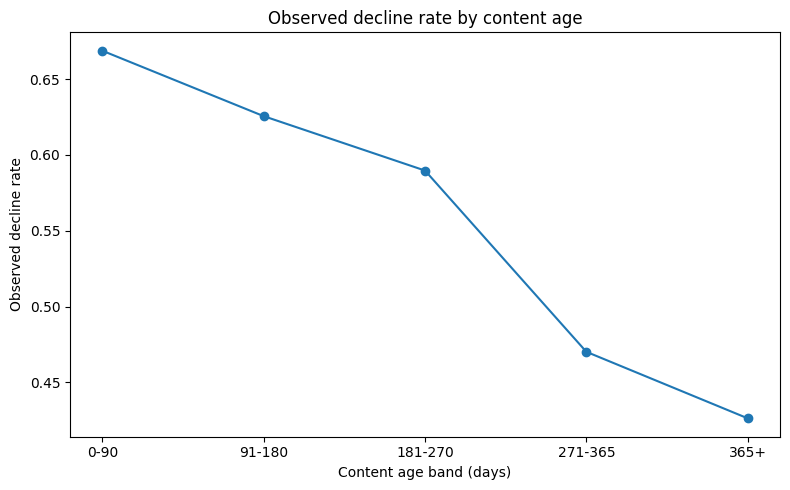

Figure exported to: /content/flyrank-ml-internship-starter/work/figures/w07_decline_rate_by_age.png
Metrics exported to: /content/flyrank-ml-internship-starter/work/outputs/w07_playbook_metrics.json

EXPORT CHECK
------------
w07_ranked_action_queue.csv -> True
w07_decay_summary.csv -> True
w07_refresh_comparison.csv -> True
w07_decline_rate_by_age.png -> True
w07_playbook_metrics.json -> True


In [8]:
# This cell is for CODE (numbers, a query, a check).
# ============================================================
# SECTION 5
# Exports for the paper
# ============================================================

from pathlib import Path
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Create output directories
# ------------------------------------------------------------

outputs_dir = Path(repo) / "work" / "outputs"
figures_dir = Path(repo) / "work" / "figures"

outputs_dir.mkdir(
    parents=True,
    exist_ok=True
)

figures_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. Export ranked queue
# ------------------------------------------------------------

queue_path = (
    outputs_dir /
    "w07_ranked_action_queue.csv"
)

action_queue.to_csv(
    queue_path,
    index=False
)

print(
    "Queue exported to:",
    queue_path
)


# ------------------------------------------------------------
# 3. Export decay summary
# ------------------------------------------------------------

decay_path = (
    outputs_dir /
    "w07_decay_summary.csv"
)

decay_summary.to_csv(
    decay_path,
    index=False
)

refresh_path = (
    outputs_dir /
    "w07_refresh_comparison.csv"
)

refresh_summary.to_csv(
    refresh_path,
    index=False
)


# ------------------------------------------------------------
# 4. Create a reusable figure
# ------------------------------------------------------------

plot_df = decay_summary.copy()

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["age_band"].astype(str),
    plot_df["decline_rate"],
    marker="o"
)

plt.xlabel("Content age band (days)")
plt.ylabel("Observed decline rate")
plt.title("Observed decline rate by content age")

plt.tight_layout()

figure_path = (
    figures_dir /
    "w07_decline_rate_by_age.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure exported to:",
    figure_path
)


# ------------------------------------------------------------
# 5. Create metrics receipt
# ------------------------------------------------------------

metrics = {
    "notebook": "w07_action_playbook.ipynb",
    "dataset_rows": int(len(df)),
    "dataset_clients": int(df["client_id"].nunique()),
    "review_rows": int(len(action_queue)),
    "training_clients": int(len(train_clients)),
    "review_clients": int(len(review_clients)),
    "client_overlap": int(len(client_overlap)),
    "top_queue_score": float(
        action_queue["validated_model_score"].max()
    ),
    "median_queue_score": float(
        action_queue["validated_model_score"].median()
    ),
    "top_20_rows": int(
        min(20, len(action_queue))
    ),
    "action_counts": {
        str(k): int(v)
        for k, v in action_queue[
            "suggested_action"
        ].value_counts().items()
    }
}

metrics_path = (
    outputs_dir /
    "w07_playbook_metrics.json"
)

with open(
    metrics_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metrics,
        f,
        indent=2
    )

print(
    "Metrics exported to:",
    metrics_path
)


# ------------------------------------------------------------
# 6. Verify files
# ------------------------------------------------------------

print("\nEXPORT CHECK")
print("------------")

for path in [
    queue_path,
    decay_path,
    refresh_path,
    figure_path,
    metrics_path
]:

    print(
        path.name,
        "->",
        path.exists()
    )

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.